📊 Model Performance Summary:



/Users/futureinlaw/Development/USIU/1.2/traffic-accident-severity-prediction/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.840503,0.754461,0.840503,0.777545
0,Logistic Regression,0.845779,0.715342,0.845779,0.775112
1,Decision Tree,0.721591,0.746224,0.721591,0.733315


<Figure size 1000x600 with 0 Axes>

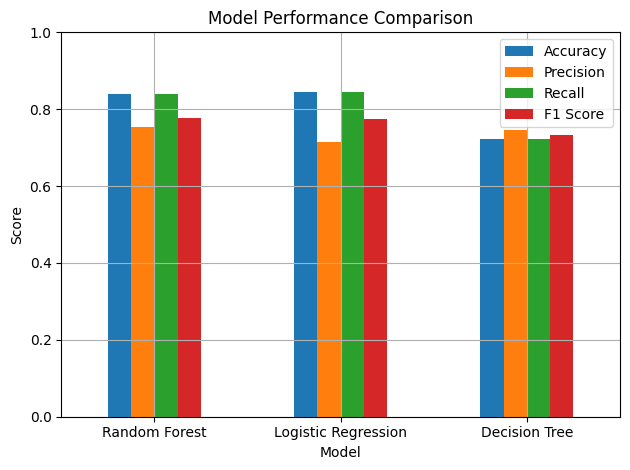

🏆 Best Performing Model: Random Forest
✅ Model and features saved to ../models/


In [4]:
# Week 5 - Model Evaluation and Reporting

# --- Step 0: Load and prepare data ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import joblib
import os

# Load cleaned dataset
df = pd.read_csv('../data/cleaned.csv')

# Columns already encoded except these:
categorical_cols = [
    'Age_band_of_driver', 'Sex_of_driver', 'Educational_level',
    'Driving_experience', 'Lanes_or_Medians', 'Types_of_Junction',
    'Road_surface_type', 'Light_conditions', 'Weather_conditions',
    'Type_of_collision', 'Vehicle_movement', 'Pedestrian_movement',
    'Cause_of_accident', 'Vehicle_driver_relation'
]

# Encode categorical features
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Split features and labels
X = df_encoded.drop(columns=['Accident_severity'])
y = df_encoded['Accident_severity']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Step 1: Train Models (again) ---
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# --- Step 2: Evaluate Models ---
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# Collect metrics
def get_metrics(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted'),
        'Recall': recall_score(y_true, y_pred, average='weighted'),
        'F1 Score': f1_score(y_true, y_pred, average='weighted')
    }

# Build results table
results = [
    get_metrics('Logistic Regression', y_test, lr_preds),
    get_metrics('Decision Tree', y_test, dt_preds),
    get_metrics('Random Forest', y_test, rf_preds)
]

results_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False)
print("📊 Model Performance Summary:\n")
display(results_df)

# Plot results
plt.figure(figsize=(10, 6))
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(kind='bar')
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Show best model
best_model_name = results_df.iloc[0]['Model']
print(f"🏆 Best Performing Model: {best_model_name}")

# Ensure the directory exists
model_dir = os.path.join(os.pardir, 'models')
os.makedirs(model_dir, exist_ok=True)

# Save the model and feature columns outside the notebooks folder
joblib.dump(rf_model, os.path.join(model_dir, 'random_forest_model.pkl'))
joblib.dump(X.columns.tolist(), os.path.join(model_dir, 'feature_columns.pkl'))

print("✅ Model and features saved to ../models/")